In [1]:
import tensorflow as tf
from tensorflow import keras

In [10]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [12]:
print(X_train.shape)  # training data shape.
print(y_train.shape)  # training data labels shape.
print(X_test.shape)   # testing data shape.
print(y_test.shape)   # testing data labels shape.

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [13]:
import matplotlib.pyplot as plt

In [17]:
import numpy as np

In [19]:
np.unique(y_train).size

10

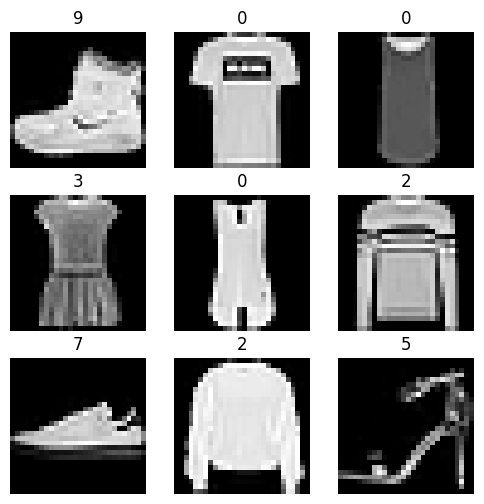

In [22]:
plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_train[i], cmap = 'gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()


In [23]:
class_names = [
    'T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot'
]

In [24]:
X_train = X_train/255.0
X_test = X_test/255.0

In [28]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape = (28, 28)),
    keras.layers.Dense(128, activation = 'relu'),
    keras.layers.Dense(10, activation = 'softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [29]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [36]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, verbose = 1, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9386 - loss: 0.1666 - val_accuracy: 0.9252 - val_loss: 0.1973
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9377 - loss: 0.1631 - val_accuracy: 0.9279 - val_loss: 0.1889
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9399 - loss: 0.1599 - val_accuracy: 0.9268 - val_loss: 0.1959
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9417 - loss: 0.1534 - val_accuracy: 0.9241 - val_loss: 0.2044
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9430 - loss: 0.1520 - val_accuracy: 0.9290 - val_loss: 0.1852
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9461 - loss: 0.1443 - val_accuracy: 0.9250 - val_loss: 0.2049
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9446 - loss: 0.1437 - val_accuracy: 0.9273 - val_loss: 0.1994
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9482 - loss: 0.1372 - 

In [37]:
print("Training accuracy: ", history.history['accuracy'][-1])

Training accuracy:  0.9490000009536743


In [38]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy: ", test_accuracy)
print("Test Loss: ", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8843 - loss: 0.4044
Test Accuracy:  0.8842999935150146
Test Loss:  0.40439754724502563


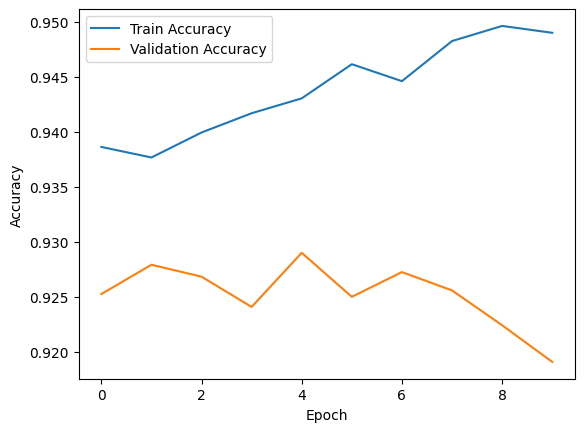

In [40]:
plt.plot(history.history['accuracy'], label = 'Train Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

- overfitting after the 4th epoch.
- so only 4 epochs were enough here. epochs 5 to 9 were actually harmful to the model's performance on new data.
- so keeping only 4 epochs and using dropout layer to reduce overfitting.


In [45]:
new_model = keras.Sequential([
    keras.layers.Flatten(input_shape = (28, 28)),
    keras.layers.Dense(128, activation = 'relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation = 'softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [46]:
new_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [47]:
new_history = new_model.fit(X_train, y_train, epochs=4, batch_size=32, verbose = 1, validation_split=0.2)

Epoch 1/4
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8067 - loss: 0.5559 - val_accuracy: 0.8530 - val_loss: 0.4143
Epoch 2/4
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8531 - loss: 0.4113 - val_accuracy: 0.8705 - val_loss: 0.3681
Epoch 3/4
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8624 - loss: 0.3783 - val_accuracy: 0.8718 - val_loss: 0.3557
Epoch 4/4
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8715 - loss: 0.3538 - val_accuracy: 0.8758 - val_loss: 0.3460


In [48]:
print("Training accuracy: ", new_history.history['accuracy'][-1])

Training accuracy:  0.8715416789054871


In [51]:
test_loss_new, test_accuracy_new = new_model.evaluate(X_test, y_test)
print("Test Accuracy: ", test_accuracy_new)
print("Test Loss: ", test_loss_new)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8602 - loss: 0.3781
Test Accuracy:  0.8601999878883362
Test Loss:  0.37809500098228455


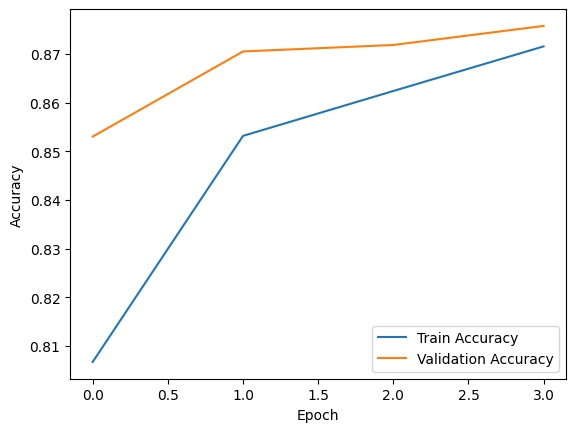

In [52]:
plt.plot(new_history.history['accuracy'], label = 'Train Accuracy')
plt.plot(new_history.history['val_accuracy'], label = 'Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


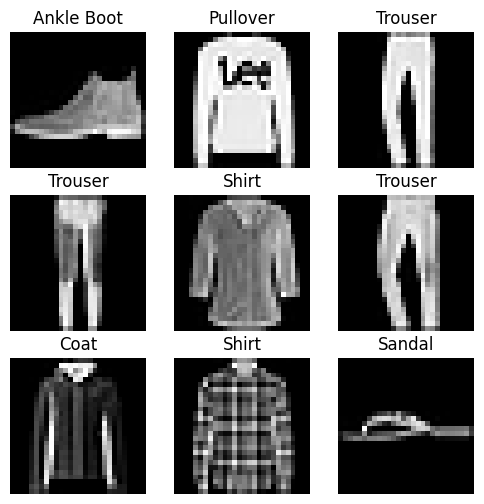

In [53]:
predictions = new_model.predict(X_test)
plt.figure(figsize = (6,6))
for i in range(9):
  plt.subplot(3, 3, i+1)
  plt.imshow(X_test[i], cmap = 'gray')
  pred_label = np.argmax(predictions[i])
  plt.title(class_names[pred_label])
  plt.axis('off')
plt.show()